Cell 1 — Import thư viện


In [2]:
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


Cell 2 — Đọc 3 tập dữ liệu


In [3]:


DATA_PATH = Path("../data/processed/split/7m")

train_df = pd.read_csv(DATA_PATH / "train.csv")
val_df = pd.read_csv(DATA_PATH / "validation.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

Train      : (4875686, 17)
Validation : (1044790, 17)
Test       : (1044790, 17)


Cell 3 — Tách Feature và Target


In [4]:
FEATURE_COLUMNS = [
    "month",
    "day_of_month",
    "day_of_week",
    "fl_date",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "crs_dep_time",
    "crs_arr_time",
    "crs_elapsed_time",
    "distance"
]

TARGET_COLUMNS = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

X_train = train_df[FEATURE_COLUMNS].copy()
Y_train = train_df[TARGET_COLUMNS].copy()

X_val = val_df[FEATURE_COLUMNS].copy()
Y_val = val_df[TARGET_COLUMNS].copy()

X_test = test_df[FEATURE_COLUMNS].copy()
Y_test = test_df[TARGET_COLUMNS].copy()

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (4875686, 12)
Y_train: (4875686, 5)
X_val: (1044790, 12)
Y_val: (1044790, 5)
X_test: (1044790, 12)
Y_test: (1044790, 5)


Cell 4 — Xác định biến categorical và numerical


In [5]:
categorical_features = [
    "op_unique_carrier",
    "origin",
    "dest"
]

numerical_features = [
    "month",
    "day_of_month",
    "day_of_week",
    "op_carrier_fl_num",
    "crs_dep_time",
    "crs_arr_time",
    "crs_elapsed_time",
    "distance"
]

MODEL_FEATURE_COLUMNS = categorical_features + numerical_features


Cell 5 — Preprocessing


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


In [7]:
print(X_train.isna().sum())
print("TOTAL NaN:", X_train.isna().sum().sum())

month                0
day_of_month         0
day_of_week          0
fl_date              0
op_unique_carrier    0
op_carrier_fl_num    0
origin               0
dest                 0
crs_dep_time         0
crs_arr_time         0
crs_elapsed_time     0
distance             0
dtype: int64
TOTAL NaN: 0


Cell 6 — Huấn luyện 5 Random Forest


In [ ]:
# Preprocess dữ liệu đúng 1 lần
preprocess_start = time.perf_counter()

X_train_encoded = preprocessor.fit_transform(
    X_train[MODEL_FEATURE_COLUMNS]
)

X_val_encoded = preprocessor.transform(
    X_val[MODEL_FEATURE_COLUMNS]
)

X_test_encoded = preprocessor.transform(
    X_test[MODEL_FEATURE_COLUMNS]
)

preprocess_time = time.perf_counter() - preprocess_start

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)
print(f"Preprocessing time: {preprocess_time:.4f} seconds")

models = {}
training_times = {}

for target in TARGET_COLUMNS:

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_encoded,
        Y_train[target]
    )

    training_time = time.perf_counter() - start_time

    models[target] = model
    training_times[target] = training_time

print("Training time:")
for target in TARGET_COLUMNS:
    print(f"{target}: {training_times[target]:.4f} seconds")

total_training_time = sum(training_times.values())
print(f"\nTotal Random Forest training time: {total_training_time:.4f} seconds")
print(f"Total pipeline time (preprocessing + training): {preprocess_time + total_training_time:.4f} seconds")


Encoded train shape: (4875686, 719)
Encoded validation shape: (1044790, 719)
Encoded test shape: (1044790, 719)
Preprocessing time: 9.6357 seconds


Cell 7 — Dự đoán trên Test


In [ ]:
Y_pred = pd.DataFrame(index=X_test.index)

for target in TARGET_COLUMNS:
    Y_pred[target] = models[target].predict(X_test_encoded)

Y_pred = Y_pred.astype(int)

print(Y_pred.head())


   carrier_delay  weather_delay  nas_delay  security_delay  \
0              0              0          0               0   
1              0              0          0               0   
2              0              0          0               0   
3              0              0          0               0   
4              0              0          0               0   

   late_aircraft_delay  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


Cell 8 — Tính Accuracy, Precision, Recall, F1


In [ ]:
results = []

for target in TARGET_COLUMNS:

    y_true = Y_test[target]
    y_pred = Y_pred[target]

    results.append({
        "Target": target,
        "Training Time (s)": training_times[target],
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Target,Training Time (s),Accuracy,Precision,Recall,F1-score
0,carrier_delay,0.773227,0.882114,0.0,0.0,0.0
1,weather_delay,0.402133,0.985772,0.0,0.0,0.0
2,nas_delay,0.681737,0.889566,0.0,0.0,0.0
3,security_delay,0.314163,0.999322,0.0,0.0,0.0
4,late_aircraft_delay,0.648739,0.888211,0.0,0.0,0.0


Cell 9 — Macro Average


In [ ]:
macro_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Macro Average": [
        results_df["Accuracy"].mean(),
        results_df["Precision"].mean(),
        results_df["Recall"].mean(),
        results_df["F1-score"].mean()
    ]
})

macro_results

,Metric,Macro Average
0,Accuracy,0.928997
1,Precision,0.000000
2,Recall,0.000000
3,F1-score,0.000000


Cell 10 — Tạo thư mục lưu kết quả


In [ ]:
FIGURE_DIR = Path("../reports/figures")
RESULT_DIR = Path("../data/processed")

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

Cell 11 — Lưu kết quả CSV


In [ ]:
results_df.to_csv(
    RESULT_DIR / "random_forest_results.csv",
    index=False,
    encoding="utf-8-sig"
)

macro_results.to_csv(
    RESULT_DIR / "random_forest_macro_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu kết quả:")
print(RESULT_DIR / "random_forest_results.csv")
print(RESULT_DIR / "random_forest_macro_results.csv")

Đã lưu kết quả:
..\data\processed\random_forest_results.csv
..\data\processed\random_forest_macro_results.csv


Cell 12 — Biểu đồ Accuracy / Precision / Recall / F1


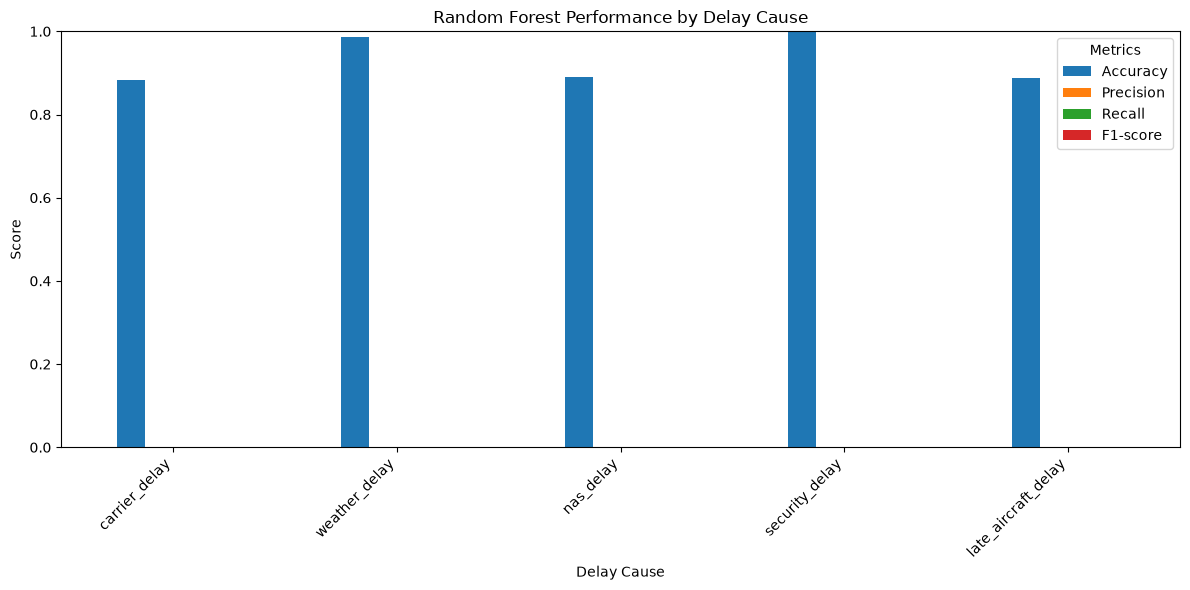

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

ax = results_df.set_index("Target")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Random Forest Performance by Delay Cause"
)

ax.set_xlabel("Delay Cause")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 13 — Confusion Matrix


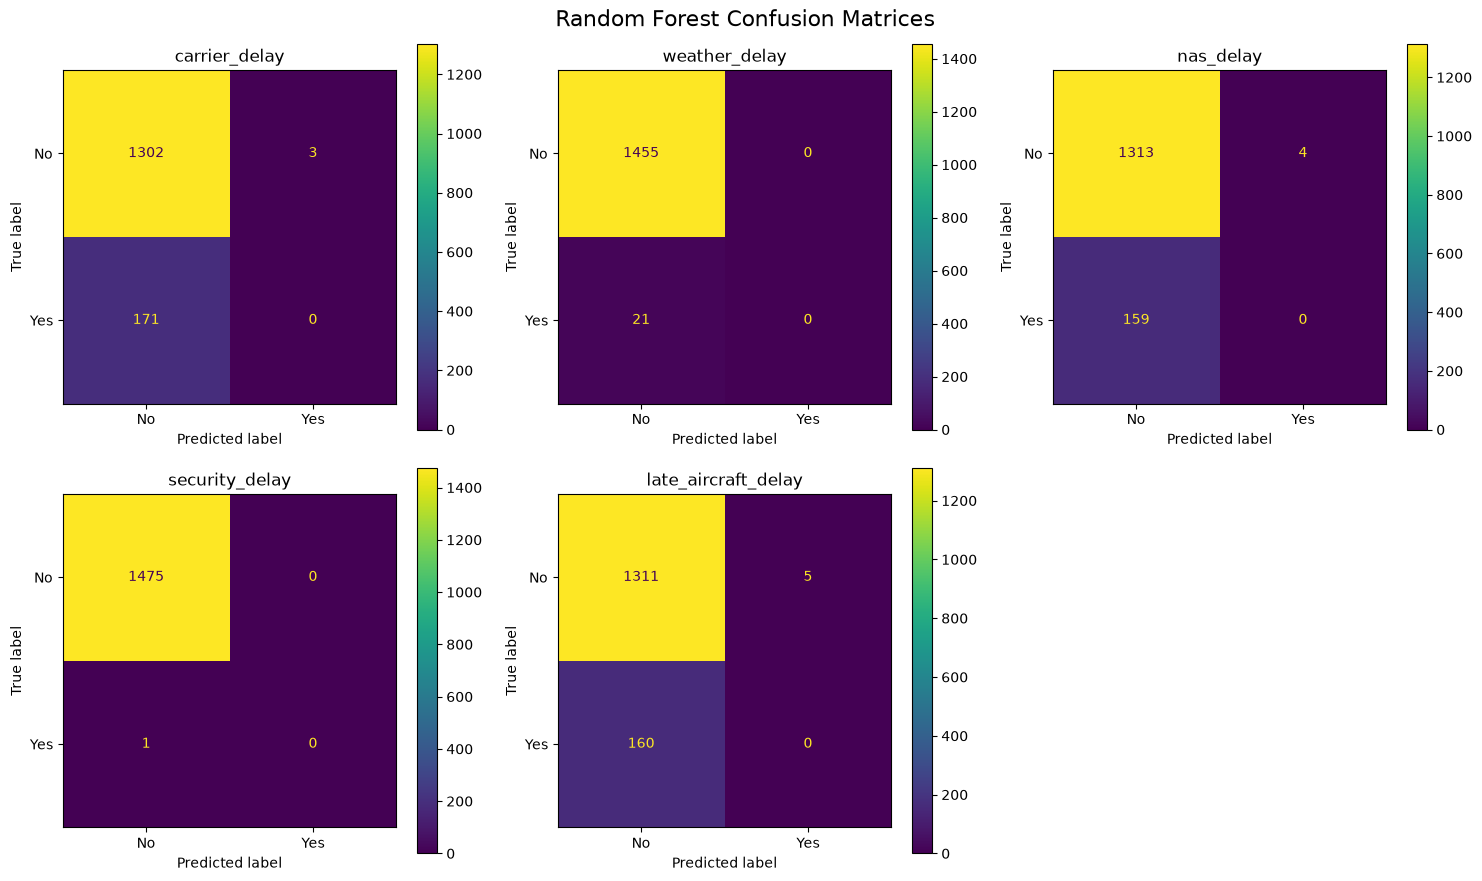

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, target in enumerate(TARGET_COLUMNS):

    cm = confusion_matrix(
        Y_test[target],
        Y_pred[target]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No", "Yes"]
    )

    disp.plot(
        ax=axes[i],
        values_format="d"
    )

    axes[i].set_title(target)

# Ô thứ 6 không sử dụng
axes[-1].axis("off")

plt.suptitle(
    "Random Forest Confusion Matrices",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()